In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

path = r'C:\Users\Anirudh\Desktop\olist_project\\'
os.chdir(path)

master = pd.read_csv('olist_master.csv')

print("Master loaded ✅")
print("Shape:", master.shape)

Master loaded ✅
Shape: (110173, 38)


In [2]:
seller_scorecard = master.groupby('seller_id').agg(
    total_orders    = ('is_late', 'count'),
    late_orders     = ('is_late', 'sum'),
    avg_delay_days  = ('delay_days', 'mean'),
    avg_review      = ('review_score', 'mean'),
    total_revenue   = ('price', 'sum')
).reset_index()

# Calculate breach rate per seller
seller_scorecard['breach_rate'] = round(
    (seller_scorecard['late_orders'] / 
     seller_scorecard['total_orders']) * 100, 2
)

# Filter sellers with at least 10 orders (avoid noise from tiny sellers)
seller_scorecard = seller_scorecard[
    seller_scorecard['total_orders'] >= 10
].reset_index(drop=True)

print("Total sellers analysed:", len(seller_scorecard))
print(seller_scorecard.describe())

Total sellers analysed: 1342
       total_orders  late_orders  avg_delay_days   avg_review  total_revenue  \
count   1342.000000  1342.000000     1342.000000  1342.000000    1342.000000   
mean      77.823398     5.723547      -11.706315     4.132259    9057.927914   
std      169.300762    14.111372        3.893233     0.440923   19715.829565   
min       10.000000     0.000000      -42.185714     1.400000     165.000000   
25%       16.000000     1.000000      -13.648214     3.920392    1474.832500   
50%       30.000000     2.000000      -11.333333     4.185185    3654.300000   
75%       73.000000     5.000000       -9.497120     4.413885    8279.825000   
max     1996.000000   206.000000       10.090909     5.000000  226987.930000   

       breach_rate  
count  1342.000000  
mean      7.254344  
std       7.571982  
min       0.000000  
25%       1.440000  
50%       5.675000  
75%      10.000000  
max      64.290000  


In [3]:
worst_sellers = seller_scorecard.sort_values(
    'breach_rate', ascending=False).head(10)

print("=== TOP 10 WORST SELLERS ===")
print(worst_sellers[['seller_id', 'total_orders', 
                      'late_orders', 'breach_rate', 
                      'avg_delay_days', 'avg_review']])

=== TOP 10 WORST SELLERS ===
                             seller_id  total_orders  late_orders  \
910   b1b3948701c5c72445495bd161b83a4c            14            9   
761   8d899e15a5925f097cca50faa49b15e3            10            6   
219   2709af9587499e95e803a6498a5a56e9            46           23   
1008  c42fd8e4d47dfb18ce5222f2dd7752f9            11            5   
1321  fce62094ffe6a4009188ec44e681dfdd            11            5   
1002  c37b2059d4f90d4feead554e5246565e            16            7   
302   38e6dada03429a47197d5d584d793b41            12            5   
18    02d35243ea2e497335cd0f076b45675d            16            6   
803   973f21788dfab357250f69a8dcb7ddee            19            7   
1051  cb41bfbcbda0aea354a834ab222f9a59            11            4   

      breach_rate  avg_delay_days  avg_review  
910         64.29        4.642857    1.928571  
761         60.00       -3.500000    2.500000  
219         50.00       -4.282609    2.600000  
1008        45.45  

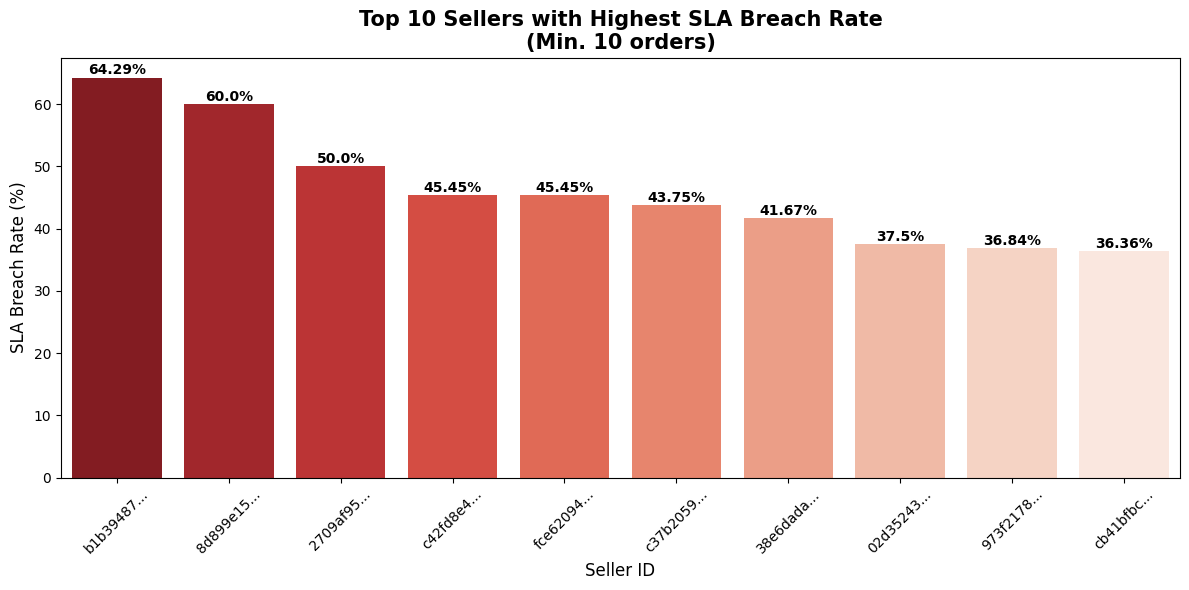

Chart 7 saved ✅


In [4]:
# Shorten seller_id for display
worst_sellers = worst_sellers.copy()
worst_sellers['seller_short'] = worst_sellers['seller_id'].str[:8] + '...'

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=worst_sellers, x='seller_short',
                   y='breach_rate', palette='Reds_r')

for bar, val in zip(bars.patches, worst_sellers['breach_rate']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.5,
              f'{val}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Sellers with Highest SLA Breach Rate\n(Min. 10 orders)',
          fontsize=15, fontweight='bold')
plt.xlabel('Seller ID', fontsize=12)
plt.ylabel('SLA Breach Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart7_worst_sellers.png', dpi=150)
plt.show()
print("Chart 7 saved ✅")

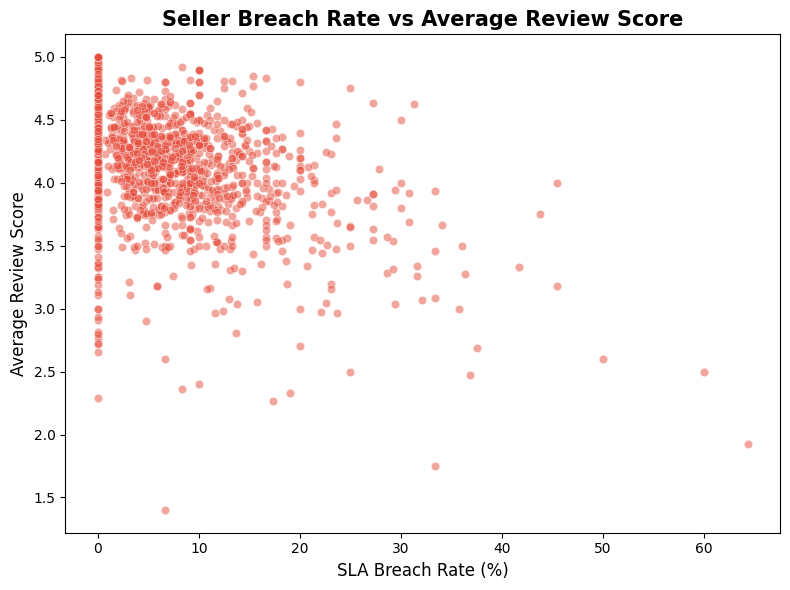

Chart 8 saved ✅


In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=seller_scorecard, x='breach_rate',
                y='avg_review', alpha=0.5, color='#e74c3c')

plt.title('Seller Breach Rate vs Average Review Score',
          fontsize=15, fontweight='bold')
plt.xlabel('SLA Breach Rate (%)', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.tight_layout()
plt.savefig('chart8_breach_vs_review.png', dpi=150)
plt.show()
print("Chart 8 saved ✅")

In [6]:
# Use English category names
category_analysis = master.groupby(
    'product_category_name_english').agg(
    total_orders   = ('is_late', 'count'),
    late_orders    = ('is_late', 'sum'),
    avg_delay_days = ('delay_days', 'mean'),
    avg_review     = ('review_score', 'mean'),
    avg_weight     = ('product_weight_g', 'mean')
).reset_index()

category_analysis['breach_rate'] = round(
    (category_analysis['late_orders'] / 
     category_analysis['total_orders']) * 100, 2
)

# Filter categories with at least 50 orders
category_analysis = category_analysis[
    category_analysis['total_orders'] >= 50
].sort_values('breach_rate', ascending=False)

print("Total categories analysed:", len(category_analysis))
print(category_analysis.head(10))

Total categories analysed: 58
   product_category_name_english  total_orders  late_orders  avg_delay_days  \
4                          audio           362           44       -9.533149   
12            christmas_supplies           150           18      -11.426667   
33       fashion_underwear_beach           127           15      -10.259843   
47                  home_confort           429           43       -9.233100   
26                   electronics          2729          240      -10.524001   
10               books_technical           263           23      -10.653992   
36                          food           499           43       -9.264529   
43                 health_beauty          9465          806      -11.367353   
57              office_furniture          1668          142      -11.245803   
56           musical_instruments           651           54      -10.910906   

    avg_review    avg_weight  breach_rate  
4     3.835196   1221.723757        12.15  
12    4.0699

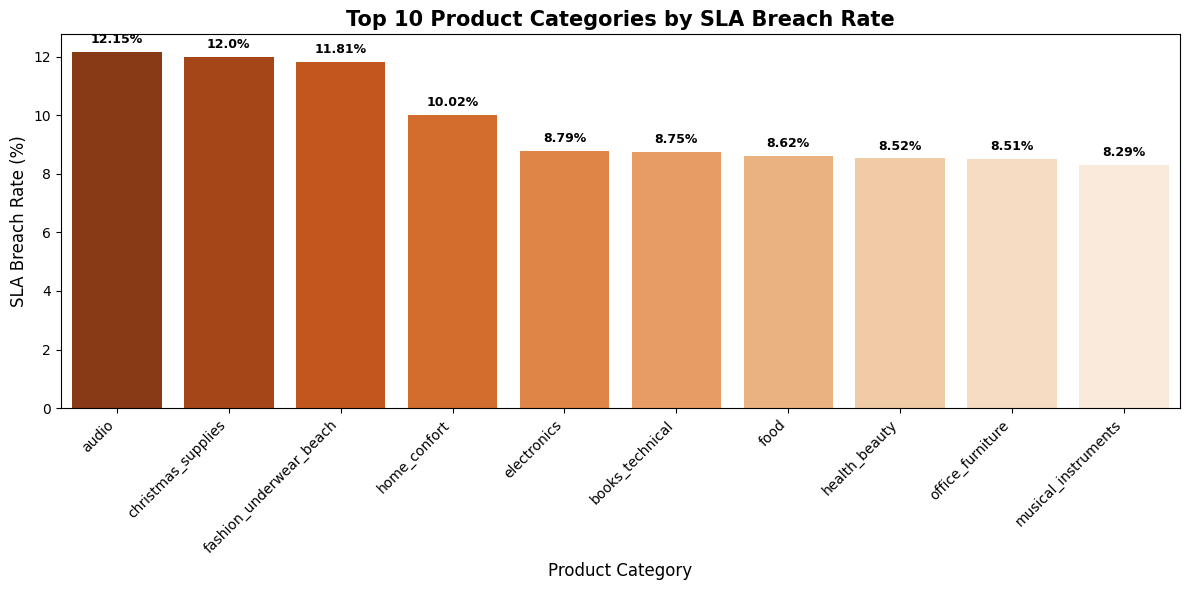

Chart 9 saved ✅


In [7]:
top10_cat = category_analysis.head(10)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=top10_cat,
                   x='product_category_name_english',
                   y='breach_rate', palette='Oranges_r')

for bar, val in zip(bars.patches, top10_cat['breach_rate']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.3,
              f'{val}%', ha='center', fontsize=9, fontweight='bold')

plt.title('Top 10 Product Categories by SLA Breach Rate',
          fontsize=15, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('SLA Breach Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart9_worst_categories.png', dpi=150)
plt.show()
print("Chart 9 saved ✅")

In [8]:
# Create weight buckets
def weight_bucket(w):
    if w <= 500:
        return 'Light (0-500g)'
    elif w <= 2000:
        return 'Medium (500g-2kg)'
    elif w <= 5000:
        return 'Heavy (2kg-5kg)'
    else:
        return 'Very Heavy (5kg+)'

master['weight_bucket'] = master['product_weight_g'].apply(weight_bucket)

weight_analysis = master.groupby('weight_bucket').agg(
    total_orders = ('is_late', 'count'),
    late_orders  = ('is_late', 'sum')
).reset_index()

weight_analysis['breach_rate'] = round(
    (weight_analysis['late_orders'] / 
     weight_analysis['total_orders']) * 100, 2
)

print(weight_analysis.sort_values('breach_rate', ascending=False))

       weight_bucket  total_orders  late_orders  breach_rate
3  Very Heavy (5kg+)         13590         1136         8.36
0    Heavy (2kg-5kg)         11149          893         8.01
2  Medium (500g-2kg)         38995         2852         7.31
1     Light (0-500g)         46439         3264         7.03


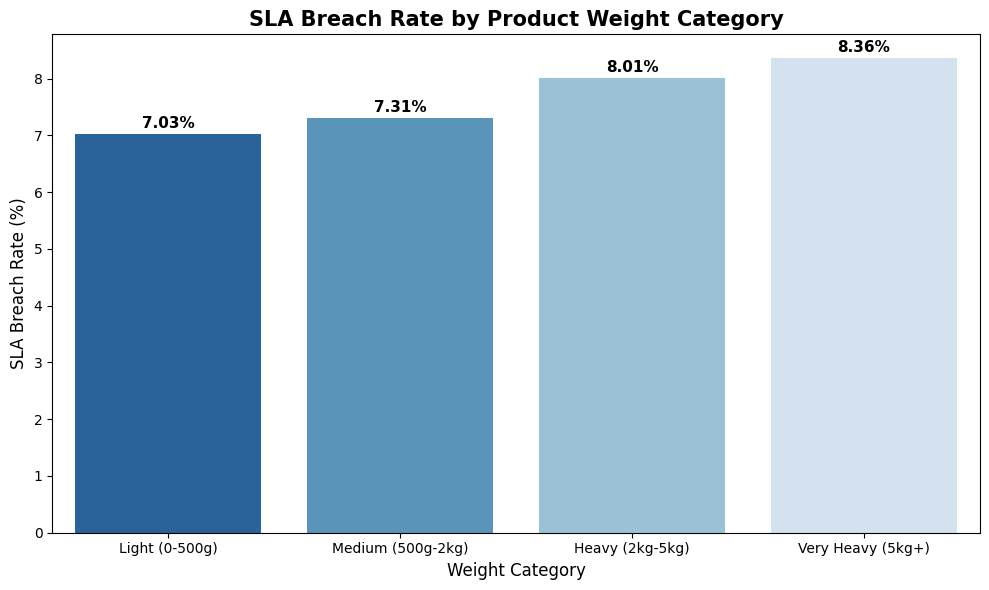

Chart 10 saved ✅


In [9]:
weight_order = ['Light (0-500g)', 'Medium (500g-2kg)',
                'Heavy (2kg-5kg)', 'Very Heavy (5kg+)']

weight_analysis = weight_analysis.set_index(
    'weight_bucket').reindex(weight_order).reset_index()

plt.figure(figsize=(10, 6))
bars = sns.barplot(data=weight_analysis, x='weight_bucket',
                   y='breach_rate', palette='Blues_r')

for bar, val in zip(bars.patches, weight_analysis['breach_rate']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.1,
              f'{val}%', ha='center', fontsize=11, fontweight='bold')

plt.title('SLA Breach Rate by Product Weight Category',
          fontsize=15, fontweight='bold')
plt.xlabel('Weight Category', fontsize=12)
plt.ylabel('SLA Breach Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('chart10_weight_vs_breach.png', dpi=150)
plt.show()
print("Chart 10 saved ✅")

In [ ]:
# ===================== DAY 4 OBSERVATIONS =====================
# 1. Total sellers analysed (min 10 orders)       = 1342
# 2. Worst seller breach rate                     = 64.29 %
# 3. Does higher breach rate = lower review score = Yes through scatter plot
# 4. Worst product category by breach rate        = Audio
# 5. Does heavier product = higher breach rate?   = Yes
# 6. One business insight from today              = Breach Rate is directly related to weight of the product and and inversely related to review score.
# ==============================================================